Потренируемся самостоятельно писать многослойный перцептрон для работы с текстами.

Возьмем для этого датасет про юридические тексты. В этом датасете есть описания дел, а в качестве цп - то, что с делами произошло.

Для начала напишем бейзлайн - логистическую регрессию. Возьмем в качестве признаков только текст - описание самого дела (case_text). Целевую переменную, очевидно, нужно превратить в чиселки (OHE).

- проверьте данные на пропуски
- проверьте баланс классов - это очень важно!
- используйте TF-IDF
- не забудьте использовать LabelEncoder
- логистической регрессии может понадобиться выставить solver='liblinear'
- если не помните, как работать с несбалансированными датасетами, просмотрите наши конспекты - точно где-то было (на худой конец документация к логрегу)

In [ ]:
!wget https://raw.githubusercontent.com/rsuh-python/mag2022/main/CL/term02/06-Embeddings/legal_text_classification.csv

--2025-01-14 23:10:49--  https://raw.githubusercontent.com/rsuh-python/mag2022/main/CL/term02/06-Embeddings/legal_text_classification.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68202412 (65M) [text/plain]
Saving to: ‘legal_text_classification.csv’

legal_text_classifi 100%[===================>]  65.04M   138MB/s    in 0.5s    

2025-01-14 23:10:52 (138 MB/s) - ‘legal_text_classification.csv’ saved [68202412/68202412]



In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
data = pd.read_csv('legal_text_classification.csv')
data.head()

,case_id,case_outcome,case_title,case_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...


In [ ]:
data.info()
# мы видим, что у нас тип данных - object, использую Label Encoding, чтобы сделать целевую переменную числом

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24985 entries, 0 to 24984
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case_id       24985 non-null  object
 1   case_outcome  24985 non-null  object
 2   case_title    24985 non-null  object
 3   case_text     24809 non-null  object
dtypes: object(4)
memory usage: 780.9+ KB


In [ ]:
# Проверка на пропуски
print(data.isnull().sum())

case_id           0
case_outcome      0
case_title        0
case_text       176
dtype: int64


In [ ]:
data.isnull().corr()

,case_id,case_outcome,case_title,case_text
case_id,NaN,NaN,NaN,NaN
case_outcome,NaN,NaN,NaN,NaN
case_title,NaN,NaN,NaN,NaN
case_text,NaN,NaN,NaN,1.0


In [ ]:

data.dropna(inplace=True)
# Так, отлично, данные почистили.

In [ ]:
data.head().copy()

,case_id,case_outcome,case_title,case_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...


In [ ]:
data.drop(['case_id'], axis=1)

,case_outcome,case_title,case_text
0,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...
1,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...
2,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...
3,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...
4,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...
...,...,...,...
24980,cited,Reches Pty Ltd v Tadiran Pty Ltd (1998) 85 FCR...,That is not confined to persons who control th...
24981,cited,Sir Lindsay Parkinson &amp; Co Ltd v Triplan L...,Once the threshold prescribed by s 1335 is sat...
24982,cited,Spiel v Commodity Brokers Australia Pty Ltd (I...,Once the threshold prescribed by s 1335 is sat...
24983,distinguished,"Tullock Ltd v Walker (Unreported, Supreme Cour...",Given the extent to which Deumer stands to gai...


In [ ]:
data['case_text_title'] = data['case_title'] + " " + data['case_text']

In [ ]:
data.head()

,case_id,case_outcome,case_title,case_text,case_text_title
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...,Dr Martens Australia Pty Ltd v Figgins Holding...


In [ ]:
data = data.drop(['case_text', 'case_title'], axis=1)

In [ ]:
data.head()

,case_id,case_outcome,case_text_title
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...


In [ ]:
data.head().copy()

,case_id,case_outcome,case_text_title
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...


In [ ]:
data = data.drop(['case_id'], axis=1)

In [ ]:
data.head().copy()

,case_outcome,case_text_title
0,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...
1,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...
2,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...
3,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...
4,cited,Dr Martens Australia Pty Ltd v Figgins Holding...


In [ ]:
data.case_outcome.value_counts() # несбалансированный класс
# case_outcome - y, case_text - x

,count
case_outcome,
cited,12110
referred to,4363
applied,2438
followed,2252
considered,1699
discussed,1018
distinguished,603
related,112
approved,108


case_outcome
cited            12110
referred to       4363
applied           2438
followed          2252
considered        1699
discussed         1018
distinguished      603
related            112
approved           108
affirmed           106
Name: count, dtype: int64


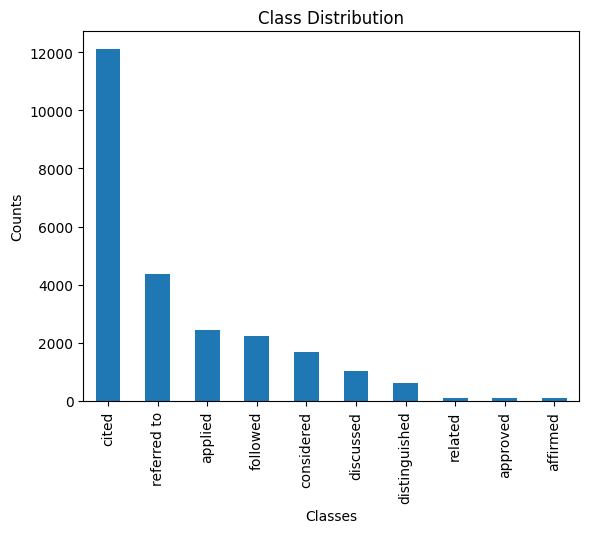

In [ ]:
# визуализирую
class_counts = data['case_outcome'].value_counts()
print(class_counts)
import matplotlib.pyplot as plt
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.show()


In [ ]:
# Подготовлю данные: Label Encoding целевой переменной и разделение на train/test
label_encoder = LabelEncoder()
data['case_outcome'] = label_encoder.fit_transform(data['case_outcome'])

X = data['case_text_title']
y = data['case_outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# TF-IDF векторизация
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
# обучу линейной линейной регрессии
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

In [ ]:
# оценю модель
from sklearn.metrics import classification_report
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.34      0.86      0.49        21
           1       0.29      0.26      0.27       488
           2       0.15      0.33      0.20        21
           3       0.67      0.68      0.68      2422
           4       0.28      0.30      0.29       340
           5       0.24      0.44      0.31       204
           6       0.24      0.45      0.31       121
           7       0.35      0.26      0.30       450
           8       0.54      0.38      0.45       873
           9       0.19      0.55      0.28        22

    accuracy                           0.50      4962
   macro avg       0.33      0.45      0.36      4962
weighted avg       0.52      0.50      0.51      4962



In [ ]:
#f1-score получилось в районе 0.5

Если все сделали как я, должна получиться средняя f-score в районе 0.5.

Теперь давайте попробуем написать нейронную сетку по аналогии с тетрадкой про твиттер из прошлого семинара.

In [ ]:
import numpy as np
from string import punctuation
from collections import Counter
from sklearn.utils import shuffle, class_weight
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim

class_weight - очень полезная для нас штука. Можно вычислить веса классов автоматически с ее помощью:

In [ ]:
# первый аргумент - какие веса высчитывать, второй - какие у нас классы, третий - какие их частоты
yweights = class_weight.compute_class_weight('balanced', classes=np.unique(data.case_outcome), y=data.case_outcome)

Заметьте, что возвращает оно np.array.

Нужно написать:

- функцию для предобработки текста, которая получает сырой текст и возвращает список токенов
- создать словарь word2id
- и обратный ему id2word

In [ ]:
train_sentences, val_sentences = train_test_split(data, test_size=0.2)

In [ ]:
import nltk
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.utils import class_weight
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
from nltk.stem import WordNetLemmatizer
import string

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
def preprocess(text):
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # удалю ссылки
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

In [ ]:
# функция для предобработки текста, которая получает сырой текст и возвращает список токенов
data['tokens'] = data['case_text_title'].apply(preprocess)

In [ ]:
from collections import Counter # Counter используется для подсчета количества вхождений элементов в последовательности
# Создание словаря частоты токенов
vocab = Counter()

In [ ]:
# выкидываем слова, которые встретили один раз
for text in data['case_text_title']:
    vocab.update(preprocess(text))
print('всего уникальных токенов:', len(vocab))

всего уникальных токенов: 54327


In [ ]:
filtered_vocab = set()
for word in vocab:
    if vocab[word] >= 1: # оставляю слова, которые встретились больше 1 раз (сделала специально, чтобы исключить больше слов, долго обучаться будет модель)
        filtered_vocab.add(word)
print('уникальных токенов, втретившихся больше 3 раз:', len(filtered_vocab))

уникальных токенов, втретившихся больше 3 раз: 54327


In [ ]:
# Создание словаря word2id с индексами
word2id = {'PAD': 0}
# должны закодироватьслова чтобы делать энкодинг
for word in filtered_vocab:
  word2id[word] = len(word2id) # каждое слово добаляется в словарь, уникальные слова

In [ ]:
#обратный словарь для того, чтобы раскодировать последовательность
id2word = {i: word for word, i in word2id.items()}

Лучше это все, конечно, запускать в колабе... не забудьте там выбрать T4 GPU в рантайме

In [ ]:
# Вычисление весов классов
yweights = class_weight.compute_class_weight('balanced', classes=np.unique(data['case_outcome']), y=data['case_outcome'])
# Преобразую в словарь для удобства
#class_weights_dict = dict(zip(np.unique(data['case_outcome']), yweights))

In [ ]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Используемое устройство:", DEVICE)

Используемое устройство: cpu


In [ ]:
MAX_LEN = 0
# добавлю паддинг
for text in data.case_text_title:
    tokens = preprocess(text)
    MAX_LEN = max(len(tokens), MAX_LEN)
MAX_LEN

12321

In [ ]:
X_tensor = []
for text in train_sentences.case_text_title:
    tokens = preprocess(text)
    ids = torch.LongTensor([word2id[token] for token in tokens if token in word2id])
    X_tensor.append(ids)

In [ ]:
X_tensor = pad_sequence(X_tensor, batch_first=True)
X_tensor.shape

torch.Size([19847, 12320])

In [ ]:
X_tensor = X_tensor[:, :100]

In [ ]:
X_tensor.shape

torch.Size([19847, 100])

In [ ]:
y_tensor = torch.LongTensor(data['case_outcome'].values).to(DEVICE)

In [ ]:
y_tensor.shape

torch.Size([24809])

Нужно написать класс для нашего датасета (можно беспощадно копипастить из тетрадки про твиттер)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torch.nn.utils.rnn import pad_sequence
from string import punctuation

In [ ]:
X_tensor = X_tensor.to(DEVICE)
y_tensor = torch.LongTensor(data['case_outcome'].values).to(DEVICE)
print("Уникальные значения меток:", np.unique(data['case_outcome'])) #проверка что метки классов соответсвуют

Уникальные значения меток: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
class LegalDataset(Dataset):

    def __init__(self, data, word2id, DEVICE):
        self.data = data['case_text_title'].values # x хранятся в тексте
        self.word2id = word2id # словарь
        self.length = data.shape[0] # длинв
        self.target = data['case_outcome'].values # тоже самое делаем
        self.device = DEVICE

    def __len__(self): #это обязательный метод, он должен уметь считать длину датасета
        return self.length

    def __getitem__(self, index): #еще один обязательный метод. По индексу возвращает элемент выборки
        tokens = self.preprocess(self.data[index]) # токенизируем
        ids = torch.LongTensor([self.word2id[token] for token in tokens if token in self.word2id]) # уже преобразованы в числа наш текст
        y = [self.target[index]]
        return ids, y # вектор текста и классы
#iloc[index]  # Предполагается, что текст в столбце 'case_text'


    def preprocess(self, text):
        tokens = text.lower().split()
        tokens = [token.strip(punctuation) for token in tokens]
        tokens = [token for token in tokens if token]
        return tokens

    def collate_fn(self, batch): #этот метод можно реализовывать и отдельно,
    # он понадобится для DataLoader во время итерации по батчам
      ids, y = list(zip(*batch)) # передается батч, он передается в виде списка кортежей, zip - соединит элементы друг с другом
      padded_ids = pad_sequence(ids, batch_first=True).to(self.device)
      y = torch.Tensor(y).to(self.device)
      return padded_ids, y

In [ ]:
train_dataset = LegalDataset(train_sentences, word2id, DEVICE)
train_sampler = RandomSampler(train_dataset)
train_iterator = DataLoader(train_dataset, collate_fn = train_dataset.collate_fn, sampler=train_sampler, batch_size=256)

In [ ]:
len(train_iterator)

78

In [ ]:
batch = next(iter(train_iterator))

In [ ]:
batch

In [ ]:
val_dataset = LegalDataset(val_sentences, word2id, DEVICE)
val_sampler = SequentialSampler(val_dataset)
val_iterator = DataLoader(val_dataset, collate_fn=val_dataset.collate_fn, sampler=val_sampler, batch_size=256)

In [ ]:
len(val_iterator)

20

In [ ]:
test_batch = next(iter(val_iterator))

Ну и наконец напишем архитектуру. Модель при инициализации должна принимать размер словаря и эмбеддинга. У нас в датасете 10 классов, поэтому, в отличие от тетрадки про твиттер, нужно использовать Softmax и возвращать вероятности классов. В качестве лосса подойдет кросс-энтропия (я ее уже за вас вписала вместе с весами классов).


# **Попытка №0**

In [ ]:
torch.manual_seed(42)
#torch.cuda.manual_seed_all(42)

In [ ]:
class MLP(nn.Module):

    def __init__(self, vocab_size, embedding_dim):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.emb2h = nn.Linear(embedding_dim, 60)
        self.act1 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)
        self.h2out = nn.Linear(60, 10)


    def forward(self, text):
        embedded = self.embedding(text)   # переводим последовательность индексов в последовательность эмбеддингов
        mean_emb = torch.mean(embedded, dim=1)
        hidden = self.emb2h(mean_emb)
        hidden = self.act1(hidden)
        hidden = self.dropout(hidden)
        out = self.h2out(hidden)
        return out

In [ ]:
batch, y = next(iter(train_iterator))

In [ ]:
yweights = torch.Tensor(yweights)# надо перевести в тензор

In [ ]:
model = MLP(len(word2id), 100)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss(weight=yweights)

model = model.to(DEVICE)
criterion = criterion.to(DEVICE)

In [ ]:
model.state_dict() # где посмотреть веса модели (ее параметры)

OrderedDict([('embedding.weight',
              tensor([[ 1.2279,  0.1879,  0.6086,  ...,  0.3193,  0.0544, -1.1947],
                      [-1.2083,  0.3882, -0.1353,  ..., -0.8758,  0.4670, -0.2454],
                      [-0.0511, -1.3216,  0.7651,  ..., -0.5724,  0.6066,  0.4385],
                      ...,
                      [-0.1056, -0.4325,  0.0903,  ...,  0.3112,  0.1363,  0.1431],
                      [-1.5397,  0.4585, -1.8661,  ...,  0.6616,  0.0948, -1.0336],
                      [-0.2914,  0.2137, -0.4483,  ...,  0.2044,  0.8432, -0.0573]],
                     device='cuda:0')),
             ('emb2h.weight',
              tensor([[-0.0883, -0.0682, -0.0217,  ...,  0.0419,  0.0338, -0.0841],
                      [ 0.0620,  0.0496, -0.0201,  ..., -0.0653, -0.0769,  0.0662],
                      [ 0.0312, -0.0588, -0.0104,  ..., -0.0947, -0.0050,  0.0486],
                      ...,
                      [ 0.0248,  0.0691,  0.0104,  ...,  0.0360,  0.0023, -0.0124],
 

Теперь нужно написать трейнлуп (лучше скопипастить откуда-нибудь), инициализировать нашу модель и запустить)

In [ ]:
from tqdm import tqdm

In [ ]:
#model = MLP(len(word2id), 100)
#optimizer = optim.Adam(model.parameters(), lr=0.005)
#criterion = nn.CrossEntropyLoss(weight=torch.tensor(yweights).float().to(DEVICE))
#model = model.to(DEVICE)
#это не нужно пока

<ipython-input-141-38a6851d9305>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(yweights).float().to(DEVICE))


In [ ]:
def train_loop(model, iterator, optimizer, criterion, scheduler=None):
    print('Training...')
    epoch_loss = 0
    model.train()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    progress_bar = tqdm(enumerate(iterator), total=len(iterator), desc="Training", leave=False)

    for i, (texts, ys) in progress_bar:
        # Перемещаю данные и метки на нужное устройство
        texts = texts.to(device)
        ys = ys.long().squeeze().to(device)

        optimizer.zero_grad()

        # прямой проход через модель
        preds_proba = model(texts)


        print(f"Outputs shape: {preds_proba.shape}")
        print(f"Targets shape: {ys.shape}")

        # вычисление потерь
        loss = criterion(preds_proba, ys)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # обновление прогресс-бар
        progress_bar.set_postfix({'Train loss': epoch_loss/(i+1)})

        if scheduler is not None:
            scheduler.step()

    return epoch_loss / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion, scheduler=None):
    print("\nValidating...")
    epoch_loss = 0
    model.eval()

    # прогресс-бар для валидации
    progress_bar = tqdm(enumerate(iterator), total=len(iterator), desc="Validating", leave=False)

    with torch.no_grad():
        for i, (texts, ys) in progress_bar:
            predictions = model(texts)
            ys = ys.long().squeeze()
            loss = criterion(predictions, ys)
            epoch_loss += loss.item()


            progress_bar.set_postfix({'Val loss': epoch_loss/(i+1)})

            if scheduler is not None:
                scheduler.step()

    return epoch_loss / len(iterator)

In [ ]:
losses = []
losses_eval = []

for i in range(50):
    print(f'\nstarting Epoch {i}')
    epoch_loss = train_loop(model, train_iterator, optimizer, criterion)
    losses.append(epoch_loss)

    epoch_loss_on_test = evaluate(model, val_iterator, criterion)
    losses_eval.append(epoch_loss_on_test)


starting Epoch 0
Training...


Training:   0%|          | 0/78 [00:00<?, ?it/s]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


Training:   3%|▎         | 2/78 [00:01<00:52,  1.46it/s, Train loss=2.31]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])
Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


...

Training:  96%|█████████▌| 75/78 [00:15<00:00,  4.19it/s, Train loss=2.29]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


Training:  97%|█████████▋| 76/78 [00:15<00:00,  3.92it/s, Train loss=2.29]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])
Outputs shape: torch.Size([135, 10])
Targets shape: torch.Size([135])

Validating...


In [ ]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.plot(losses_eval)
plt.title('Сross Entropy value')
plt.ylabel('Cross Entropy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

NameError: name 'losses' is not defined

In [ ]:
torch.manual_seed(42)


# **Эмбеддинги**

In [ ]:
import multiprocessing
from gensim.models import Word2Vec
import gensim.downloader as api
import gensim

In [ ]:
glove = gensim.downloader.load('glove-twitter-50')

[==================================================] 100.0% 199.5/199.5MB downloaded


In [ ]:
glove.vector_size

50

In [ ]:
filtered_vocab = set()
for word in vocab:
    if vocab[word] >= 1: # оставляю слова, которые встретились больше 3 раз (сделала специально, чтобы исключить больше слов, долго обучаться будет модель)
        filtered_vocab.add(word)
print('уникальных токенов, втретившихся больше 3 раз:', len(filtered_vocab))

уникальных токенов, втретившихся больше 3 раз: 54327


In [ ]:
# for word in filtered_vocab:
#   print(glove[word])
#   break
filtered_embeddings = {word: glove[word] for word in filtered_vocab if word in glove} # беру эмбеддинги слов которые есть в filtered vocab

frick [ 0.92061   0.73672   0.57908  -0.40384  -0.031596 -0.78791   0.18833
 -0.13858   0.6765    0.029008  0.20438   0.089397 -1.8805   -0.029112
 -0.29076  -0.043467 -0.15206   0.18143  -0.34145   0.6235    0.11856
  0.32642  -0.21647   0.90775  -0.19172   1.0216    0.66325   1.2348
  0.40139  -0.33284  -0.36705   0.032314  1.7069   -1.053    -0.81782
  0.5832   -0.55541  -0.25407   0.60697   0.95485   0.75869  -0.17001
 -0.86416   0.55527  -0.69324   0.42448   1.1157    0.08123  -0.25143
  1.224   ]


In [ ]:
# print(filtered_embeddings)

In [ ]:
from gensim.models import KeyedVectors
import gensim.downloader as api
kv = KeyedVectors(vector_size=50)
words_list = []
embeddings_list = []
print(len(list(filtered_embeddings.keys())))
for words in filtered_embeddings.keys():
  words_list.append(word)
  embeddings_list.append(filtered_embeddings.get(word))
kv.add_vectors(words_list, embeddings_list)

# filtered_embeddings.save('filtered_embeddings.kv')
# filtered_embeddings = KeyedVectors.load('filtered_embeddings.kv')

25046


In [ ]:
print(kv)
kv.save('embeddings_test.kv')

KeyedVectors<vector_size=50, 25046 keys>


In [ ]:
another_kv = KeyedVectors.load('embeddings_test.kv')

In [ ]:
# размеры векторов
embedding_dim = another_kv.vector_size
vocab_size = len(another_kv.index_to_key)
# embedding_dim = filtered_embeddings.vector_size
# vocab_size = len(filtered_embeddings.index_to_key)

In [ ]:
print(f"Embedding matrix shape: {embedding_dim}")
print(f"Vocab size: {vocab_size}")

Embedding matrix shape: 50
Vocab size: 25046


In [ ]:
# Инициализация матрицы эмбеддингов
embedding_matrix = torch.zeros((vocab_size, embedding_dim))

In [ ]:
# Заполнение матрицы:
for i, word in enumerate(another_kv.index_to_key):
    if i >= vocab_size:
        break
    embedding_matrix[i] = torch.tensor(another_kv[word])

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
embedding_matrix = embedding_matrix.to(DEVICE)

In [ ]:
#yweights = torch.Tensor(yweights)# надо перевести в тензор
yweights = torch.Tensor(yweights).to(DEVICE)

In [ ]:
class MLP1(nn.Module):
    def __init__(self, vocab_size, embedding_dim, pretrained_embeddings):
        super(MLP1, self).__init__()  # Исправлено на правильный вызов суперкласса
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=True)
        self.emb2h1 = nn.Linear(embedding_dim, 60)  # 128
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.5)

        self.emb2h2 = nn.Linear(60, 30)  # 128 -> 64
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.5)

        self.h2out = nn.Linear(30, 10)  # 64 -> 10

    def forward(self, text):
        embedded = self.embedding(text)  # переводим последовательность индексов в последовательность эмбеддингов
        mean_emb = torch.mean(embedded, dim=1)  # считаем средний эмбеддинг предложения

        hidden1 = self.emb2h1(mean_emb)  # пропускаем эмбеддинг через полносвязный слой
        hidden1 = self.act1(hidden1)
        hidden1 = self.dropout1(hidden1)

        hidden2 = self.emb2h2(hidden1)
        hidden2 = self.act2(hidden2)
        hidden2 = self.dropout2(hidden2)

        out = self.h2out(hidden2)  # возвращаем одно число для каждого семпла
        return out

In [ ]:
model2 = MLP1(vocab_size=vocab_size, embedding_dim=embedding_dim, pretrained_embeddings=embedding_matrix)
optimizer = optim.AdamW(model2.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-08)
criterion = nn.CrossEntropyLoss(weight=yweights)
model2 = model2.to(DEVICE)

In [ ]:
from tqdm import tqdm
def train_loop(model2, iterator, optimizer, criterion, scheduler=None):
    print('Training...')
    epoch_loss = 0
    model2.train()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    progress_bar = tqdm(enumerate(iterator), total=len(iterator), desc="Training", leave=False)

    for i, (texts, ys) in progress_bar:
        texts = texts.to(device)
        ys = ys.long().squeeze().to(device)

        optimizer.zero_grad()

        print("Max index in texts:", texts.max())

        assert (texts >= 0).all(), "Negative indices found in input"
        assert (texts < vocab_size).all(), "Indices out of range found in input"


        preds_proba = model2(texts)
        model2()


        #print(f'Outputs shape: {preds_proba.shape}')
        #print(f'Targets shape: {ys.shape}')
        loss = criterion(preds_proba, ys)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix({'Train loss': epoch_loss/(i+1)})

        if scheduler is not None:
            scheduler.step()

    return epoch_loss / len(iterator)

In [ ]:
def evaluate(model2, iterator, criterion, scheduler=None):
    print('\nValidating...')
    epoch_loss = 0
    model2.eval()

    progress_bar = tqdm(enumerate(iterator), total=len(iterator), desc='Validating', leave=False)

    with torch.no_grad():
        for i, (texts, ys) in progress_bar:
            texts = torch.clamp(texts, 0, vocab_size - 1)
            predictions = model(texts)
            ys = ys.long().squeeze()
            loss = criterion(predictions, ys)
            epoch_loss += loss.item()

            progress_bar.set_postfix({'Val loss': epoch_loss/(i+1)})

            if scheduler is not None:
                scheduler.step()

    return epoch_loss / len(iterator)

In [ ]:
losses2 = []
losses_eval2 = []

for i in range(50):
    print(f'\nstarting Epoch {i}')
    epoch_loss2 = train_loop(model2, train_iterator, optimizer, criterion)
    losses2.append(epoch_loss2)

    epoch_loss_on_test2 = evaluate(model2, val_iterator, criterion)
    losses_eval2.append(epoch_loss_on_test2)


starting Epoch 0
Training...


Max index in texts: tensor(30737)


AssertionError: Indices out of range found in input

Из-за этой ошибки не могу продолжить обучение, очень долго пыталась ее решить, но оставила уже как есть.

Как я поняла из glove многие слова не подходят под то, с чем я работаю, взяла не самый удачный glove-twitter-50


# **Попытка №1**

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
class MLP3(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embeddings_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Инициализируем слой nn.Embedding матрицей weights
        self.embedding.weight = nn.Parameter(torch.tensor(embeddings_matrix, dtype=torch.float32)) # вроде как здесь должны переноситься эмбеддинги в класс модели
        self.emb_1 = nn.Linear(embedding_dim, 50) # передаем на скрытый слой
        self.batchnorm1 = nn.BatchNorm1d(50)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.2)

        self.emb_2 = nn.Linear(50, 30)
        self.batchnorm2 = nn.BatchNorm1d(30)
        self.act2 = nn.Softmax(dim=1)
        self.dropout2 = nn.Dropout(p=0.2)
        self.h2out = nn.Linear(30, 10)


    def forward(self, text):
        embedded = self.embedding(text)
        mean_emb = torch.mean(embedded, dim=1)
        # пропускаем эмбеддинг через полносвязный слой
        hidden = self.emb_1(mean_emb)
        hidden = self.batchnorm1(hidden)
        hidden = self.act1(hidden)
        hidden = self.dropout1(hidden)
        hidden2 = self.emb_2(hidden)
        hidden2 = self.batchnorm2(hidden2)
        hidden2 = self.act2(hidden2)
        hidden2 = self.dropout2(hidden2)
        out = self.h2out(hidden2)
        return out

In [ ]:
model3 = MLP3(len(word2id), 50, embeddings_matrix)
optimizer_adamw = optim.AdamW(model3.parameters(), lr=0.001, eps=1e-08)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(yweights).float().to(DEVICE))
model3 = model3.to(DEVICE)

<ipython-input-116-13c876981cd0>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(yweights).float().to(DEVICE))


In [ ]:
def train_loop(model, iterator, optimizer, criterion, scheduler=None):
    print('Training...')
    epoch_loss = 0
    model.train()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    progress_bar = tqdm(enumerate(iterator), total=len(iterator), desc="Training", leave=False)

    for i, (texts, ys) in progress_bar:
        # Перемещаем данные и метки на нужное устройство
        texts = texts.to(device)
        ys = ys.long().squeeze().to(device)

        optimizer.zero_grad()

        # Прямой проход через модель
        preds_proba = model(texts)

        # Печатаем размеры для отладки
        print(f"Outputs shape: {preds_proba.shape}")
        print(f"Targets shape: {ys.shape}")

        # Вычисление потерь
        loss = criterion(preds_proba, ys)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # Обновляем прогресс-бар, выводя текущее значение лосса
        progress_bar.set_postfix({'Train loss': epoch_loss/(i+1)})

        if scheduler is not None:
            scheduler.step()

    return epoch_loss / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion, scheduler=None):
    print("\nValidating...")
    epoch_loss = 0
    model.eval()

    # Добавляем прогресс-бар для валидации
    progress_bar = tqdm(enumerate(iterator), total=len(iterator), desc="Validating", leave=False)

    with torch.no_grad():
        for i, (texts, ys) in progress_bar:
            predictions = model(texts)
            ys = ys.long().squeeze()
            loss = criterion(predictions, ys)
            epoch_loss += loss.item()

            # Обновляем прогресс-бар, выводя текущее значение лосса
            progress_bar.set_postfix({'Val loss': epoch_loss/(i+1)})

            if scheduler is not None:
                scheduler.step()

    return epoch_loss / len(iterator)

In [ ]:
losses_1 = []
losses_eval_1 = []

for i in range(20):
    print(f'\nstarting Epoch {i}')
    epoch_loss = train_loop(model3, train_iterator, optimizer, criterion)
    losses.append(epoch_loss)

    epoch_loss_on_test = evaluate(model3, val_iterator, criterion)
    losses_eval.append(epoch_loss_on_test)


starting Epoch 0
Training...


Training:   0%|          | 0/78 [00:00<?, ?it/s]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


Training:   1%|▏         | 1/78 [00:02<03:17,  2.56s/it, Train loss=2.31]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


...

Training:  55%|█████▌    | 43/78 [01:10<01:06,  1.91s/it, Train loss=2.31]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


Training:  56%|█████▋    | 44/78 [01:13<01:07,  2.00s/it, Train loss=2.31]

Outputs shape: torch.Size([256, 10])
Targets shape: torch.Size([256])


KeyboardInterrupt: 

In [ ]:
# остановила, т.к не падала ошибка

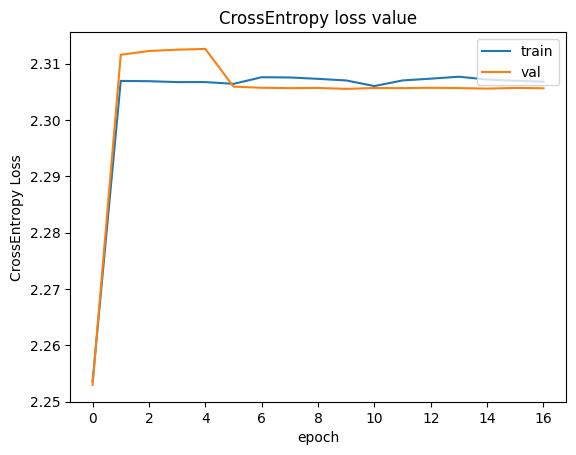

In [ ]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.plot(losses_eval)
plt.title('CrossEntropy loss value')
plt.ylabel('CrossEntropy Loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

In [ ]:
# ошибка не падает, это была попытка 1, когда я немного поменяла архитектуру

Скорее всего, вам понадобится учиться очень много эпох, чтобы предсказывать что-нибудь стоящее (эпох 100...), и, вероятнее всего, придется играться с архитектурой, чтобы получить приличное качество. На семинаре на эксперименты времени нет, поэтому добаловаться можно дома - и заодно попробовать подключить эмбеддинги w2v, например.